## EDA of the FractAtlas Dataset

### 1. Data Loading and Investigation

In [10]:
# import needed libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import json
from collections import defaultdict

In [11]:
# load the metadata from dataset.csv

metadata = pd.read_csv('FracAtlas/dataset.csv')
print("Shape of the dataset", metadata.shape)
# prints in a table format the first 10 entries of the dataset.csv dataset
metadata.head(10)

Shape of the dataset (4083, 13)


,image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
0,IMG0000000.jpg,0,1,0,0,0,0,1,0,0,1,1,0
1,IMG0000001.jpg,0,1,0,0,0,0,1,0,0,1,1,0
2,IMG0000002.jpg,0,1,0,0,0,0,1,0,0,1,1,0
3,IMG0000003.jpg,0,1,0,0,0,0,1,0,0,0,1,1
4,IMG0000004.jpg,0,1,0,0,0,0,1,0,0,0,1,1
5,IMG0000005.jpg,0,1,0,0,0,0,1,0,0,0,1,1
6,IMG0000006.jpg,1,0,0,0,0,0,1,0,0,0,1,1
7,IMG0000007.jpg,1,0,0,0,0,0,0,0,0,0,0,1
8,IMG0000008.jpg,0,1,0,0,0,0,1,0,0,0,1,1
9,IMG0000009.jpg,0,1,0,0,0,0,0,0,0,0,0,1


#### Dataset Shape and Features

Our dataset consists of 4083 samples between fractures, non-fractures, and varying fracture type X-Ray images. 13 features are included with each image, in order to indicate: 
 * The fracture type (hand, leg, hip, shoulder, mixed, and hardware)
 * The orientation of the X-Ray (frontal, lateral, and oblique)
 * If the image does contain a fracture (fractured)
 * If the image has other X-Rays in the dataset of the same patient and the same area, just a different orientation of the body part (frontal, lateral, oblique orientation)

The image_id field indicates which X-Ray image in the Fractured or Non_fractured sub folders that the metadata coorelates to.

#### Dataset Source

The FracAtlas dataset is a publiclly available dataset free for use and download. It can be found here: https://figshare.com/articles/dataset/The_dataset/22363012?file=43283628

#### Dataset Structure

The FracAtlas dataset downloads from the aformentioned url in a zip folder. Once unzipped there are 3 sub folders:
 * Annotations
 * images
 * Utilities
And one dataset.csv file, which contains the metadata for the entire dataset.

Within the images folder, there are an additional two sub folders:
 * Fractured
 * Non_fractured

These two folders contain all the X-Ray images for the dataset, and as labeled, the Fractured folder contains all the X-Ray images that include a fracture, and the Non_fractued folder contains all the X-Ray images that do not have a fracture.

Within the Utilities folder, there are two Jupyter Notebooks that will not be used, and a sub folder:
 * Fracture Split

The Fracture Split sub folder contains three csv files (test, train, valid) which each contain some of the image_ids from the dataset.csv file. These csv files are meant to indicate the train, validation, and test split for the data and will be used accordingly.

The Annotations folder contains four different annotation formats for the dataset including YOLO, PASCAL VOC, COCO JSON and vGG JSON.

### 2. Feature-level analysis

#### Understanding of Fracture type Distribution

From the 6 graphs below, we can see the distribution of fracture types within the metadata for the FracAtlas dataset. Here, a '0' on the x-axis indicates that the specified type of fracture is not present, and a '1' indicates that the fracture type is present in the X-Ray image.

From this, we can see that the majority of fractures in the X-Ray images are those of Hand and Leg fractures, with Hip, Shoulder, images with Mixed fractures, and images with Hardware included making up a small portion of the dataset.

Because of this, class balancing will be needed in order to properly represent all fracture types in the models.

In [12]:
def add_labels(ax):
    """Add count labels on top of each bar in a bar plot."""
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 1,  # adjust +1 for spacing
                f'{int(height)}', ha='center', va='bottom', fontsize=30)

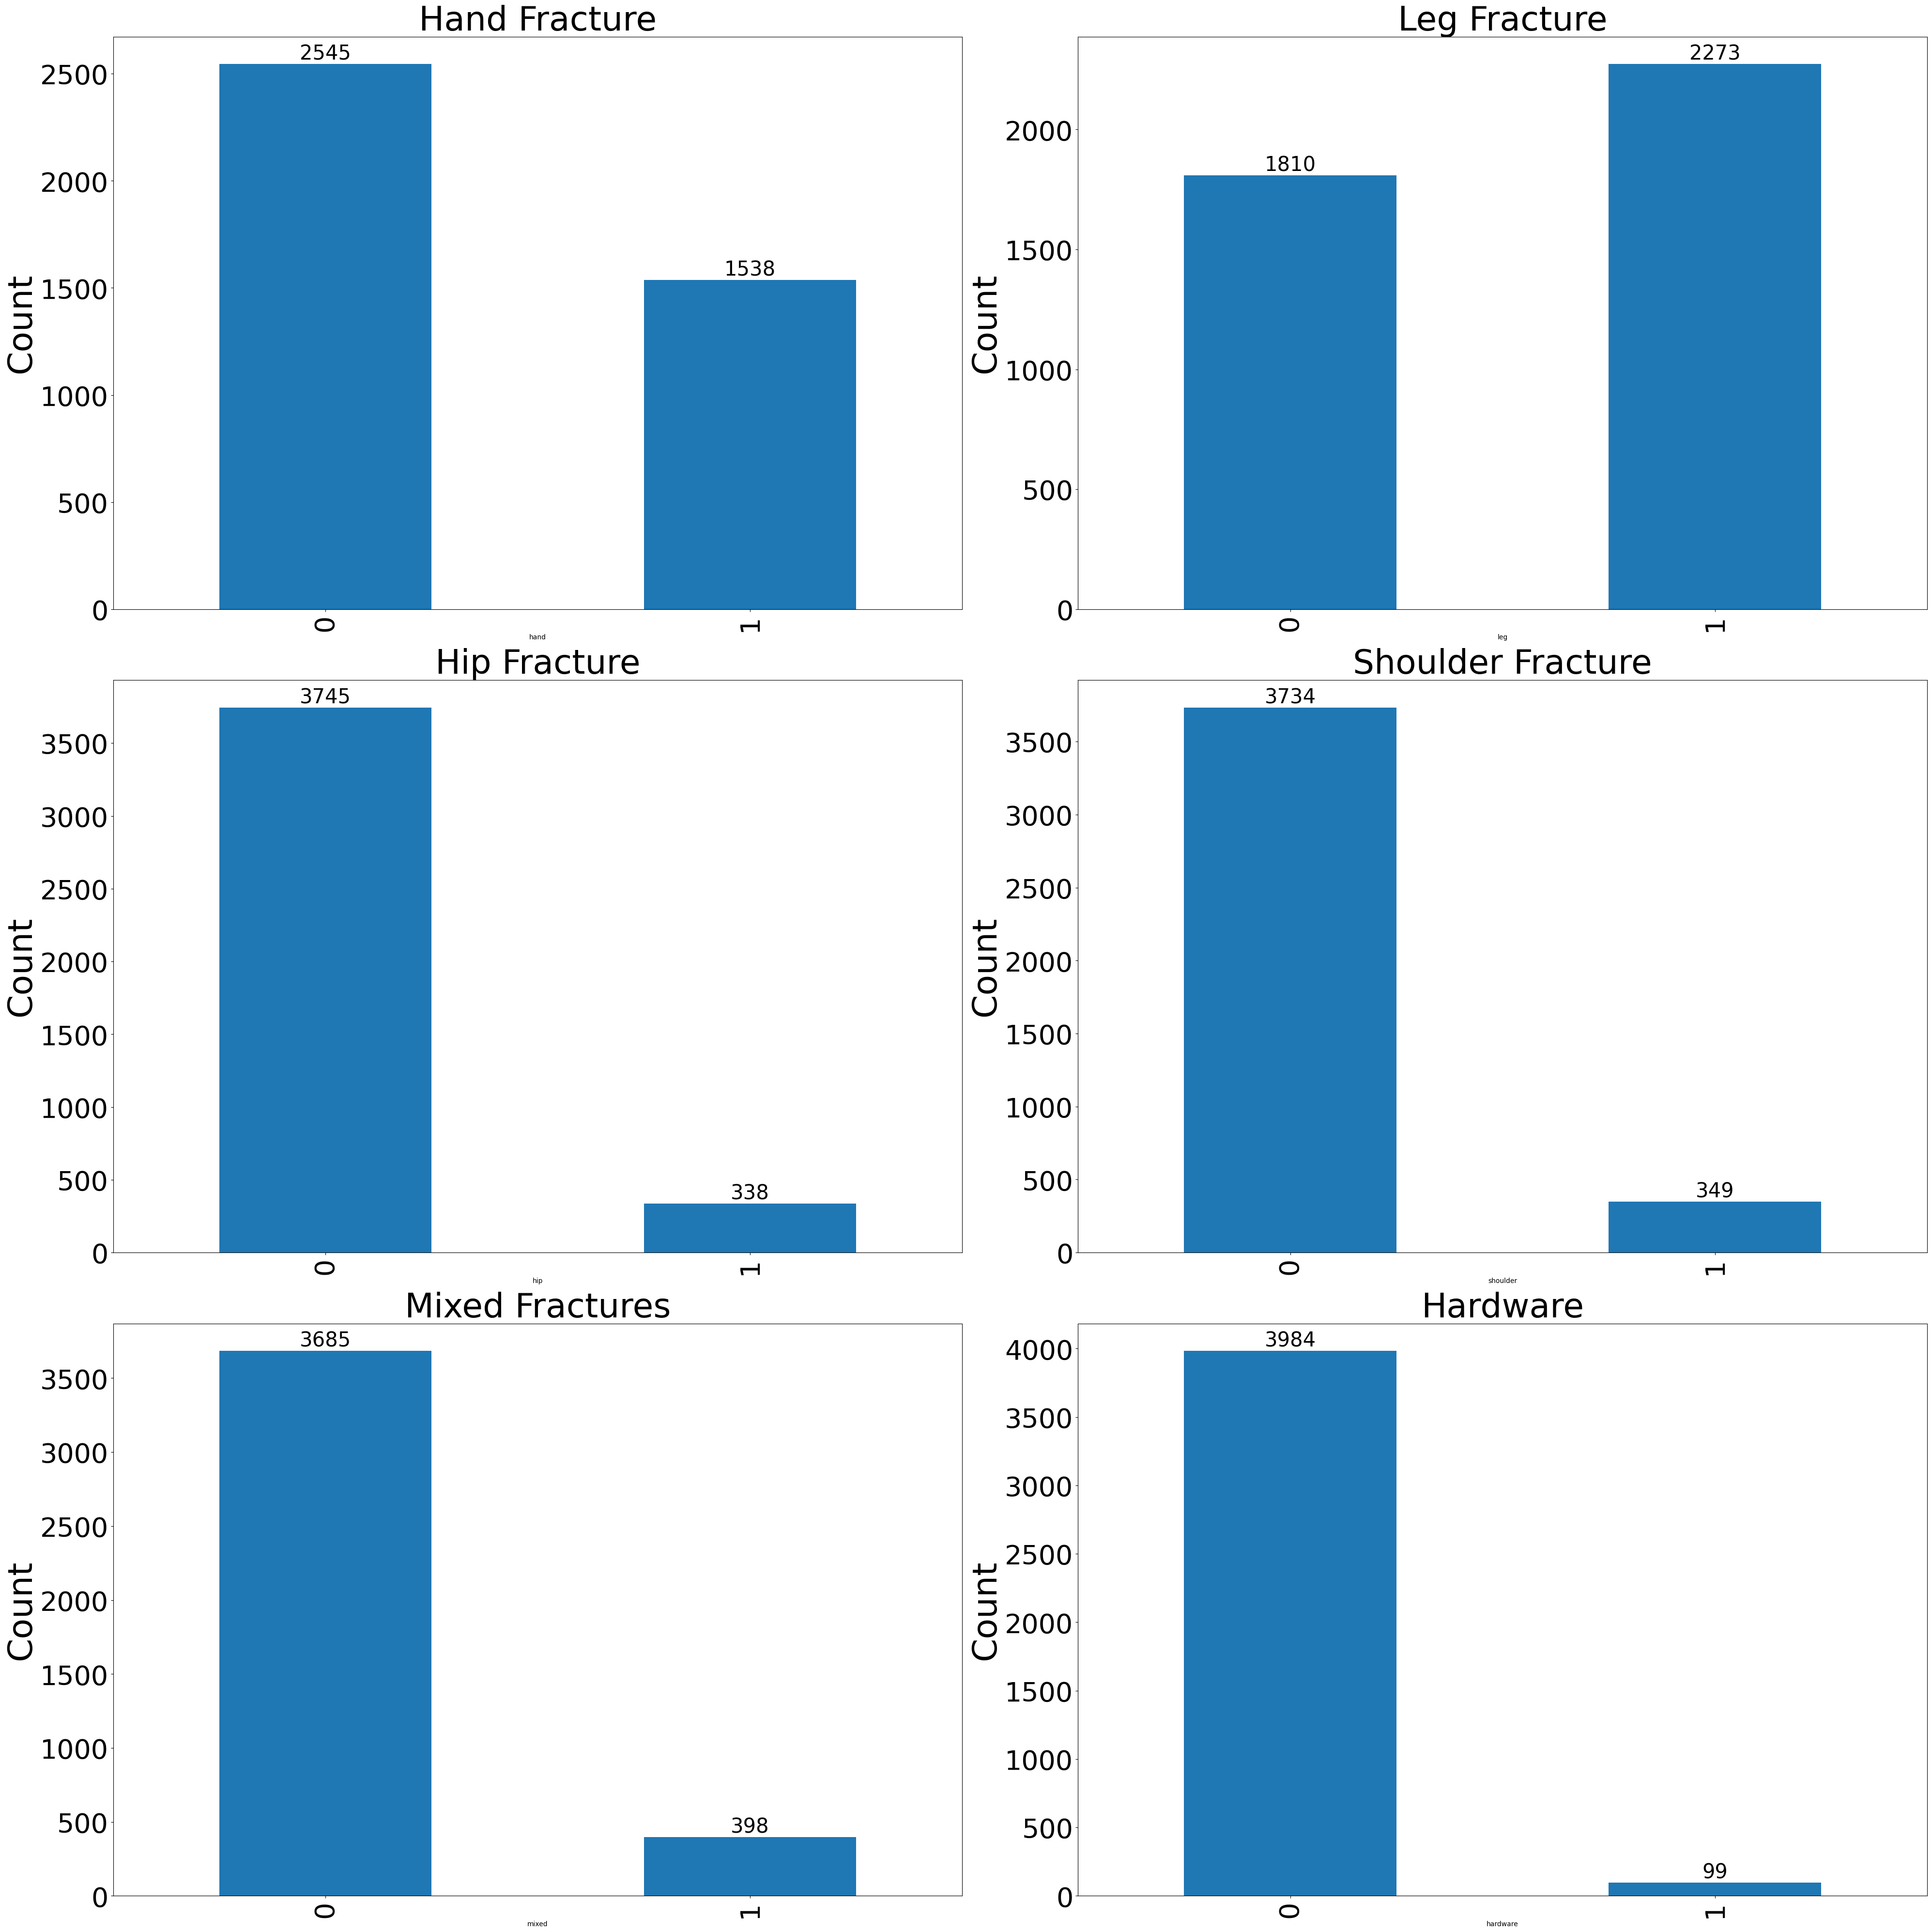

In [13]:
# Getting a sense of what the distribution between fracture types and the presence of hardware

fig = plt.figure(figsize=(40, 40))

# Define font size for tick labels
tick_label_size = 40  

ax1 = fig.add_subplot(321)
metadata['hand'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count', size=50)
ax1.set_title('Hand Fracture', size=50)
ax1.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax1)

ax2 = fig.add_subplot(322)
metadata['leg'].value_counts().sort_index().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count', size=50)
ax2.set_title('Leg Fracture', size=50)
ax2.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax2)


ax3 = fig.add_subplot(323)
metadata['hip'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_ylabel('Count', size=50)
ax3.set_title('Hip Fracture', size=50)
ax3.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax3)


ax4 = fig.add_subplot(324)
metadata['shoulder'].value_counts().plot(kind='bar', ax=ax4)
ax4.set_ylabel('Count', size=50)
ax4.set_title('Shoulder Fracture', size=50)
ax4.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax4)


ax5 = fig.add_subplot(325)
metadata['mixed'].value_counts().plot(kind='bar', ax=ax5)
ax5.set_ylabel('Count', size=50)
ax5.set_title('Mixed Fractures', size=50)
ax5.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax5)


ax6 = fig.add_subplot(326)
metadata['hardware'].value_counts().plot(kind='bar', ax=ax6)
ax6.set_ylabel('Count', size=50)
ax6.set_title('Hardware', size=50)
ax6.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax6)

plt.tight_layout()
plt.show()

The bar chart below shows how often each anatomical region—hand, leg, hip, and shoulder—appears in the dataset. Since some images include more than one region, the total count across all bars is higher than the actual number of unique images.

There’s a clear imbalance, with leg and hand regions appearing much more frequently than hip and shoulder. This could affect the model’s ability to generalize across all areas, especially if it sees fewer examples from the less common regions during training. It’s something we'll keep in mind when analyzing results or evaluating model performance.



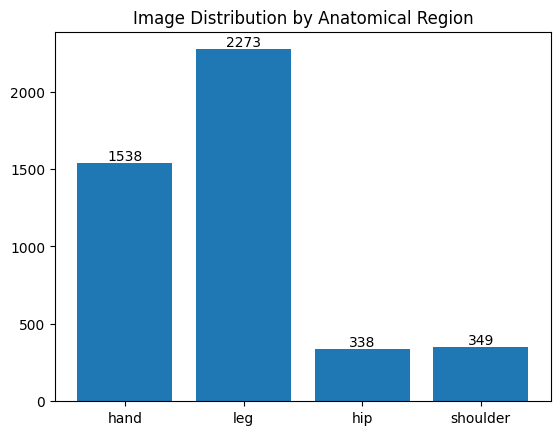

In [20]:
region_count = [metadata['hand'].sum(), metadata['leg'].sum(), metadata['hip'].sum(), metadata['shoulder'].sum()]
x_labels = ['hand', 'leg', 'hip', 'shoulder']
plt.bar(x_labels, region_count)
# Annotate each bar
for i, value in enumerate(region_count):
    plt.text(i, value + 0.1, str(value), ha='center', va='bottom')
plt.title('Image Distribution by Anatomical Region')
plt.show()

#### Understanding of Fracture Distribution and Fracture Image Orientation Distribution

The 6 graphs below are to represent the distribution of a few different aspects of the dataset. 

The first graph titled Multiscan is meant to show how many images in the dataset show the same fracture from different orientations, where '0' indicates no multiscans and '1' indicates a fracture has multiscans.
The second graph, Fractured, is to indicate how many images in the dataset contain a fracture, with '0' indicating no fracture and '1' indicating a fracture is present. As we can see this class distribution is rather imbalanced, and will need some preprocessing in order to correct the class imbalance to properly train the neural networks.
The third graph, Fracture Count, indicates the count for each type of fracture, ie: Hand, Leg, Shoulder ...
The fourth, fith, and sixth graphs show the distribution of the orientation of the X-Ray image. Meaning is the X-Ray is a Frontal, Lateral, or Oblique orientated image.

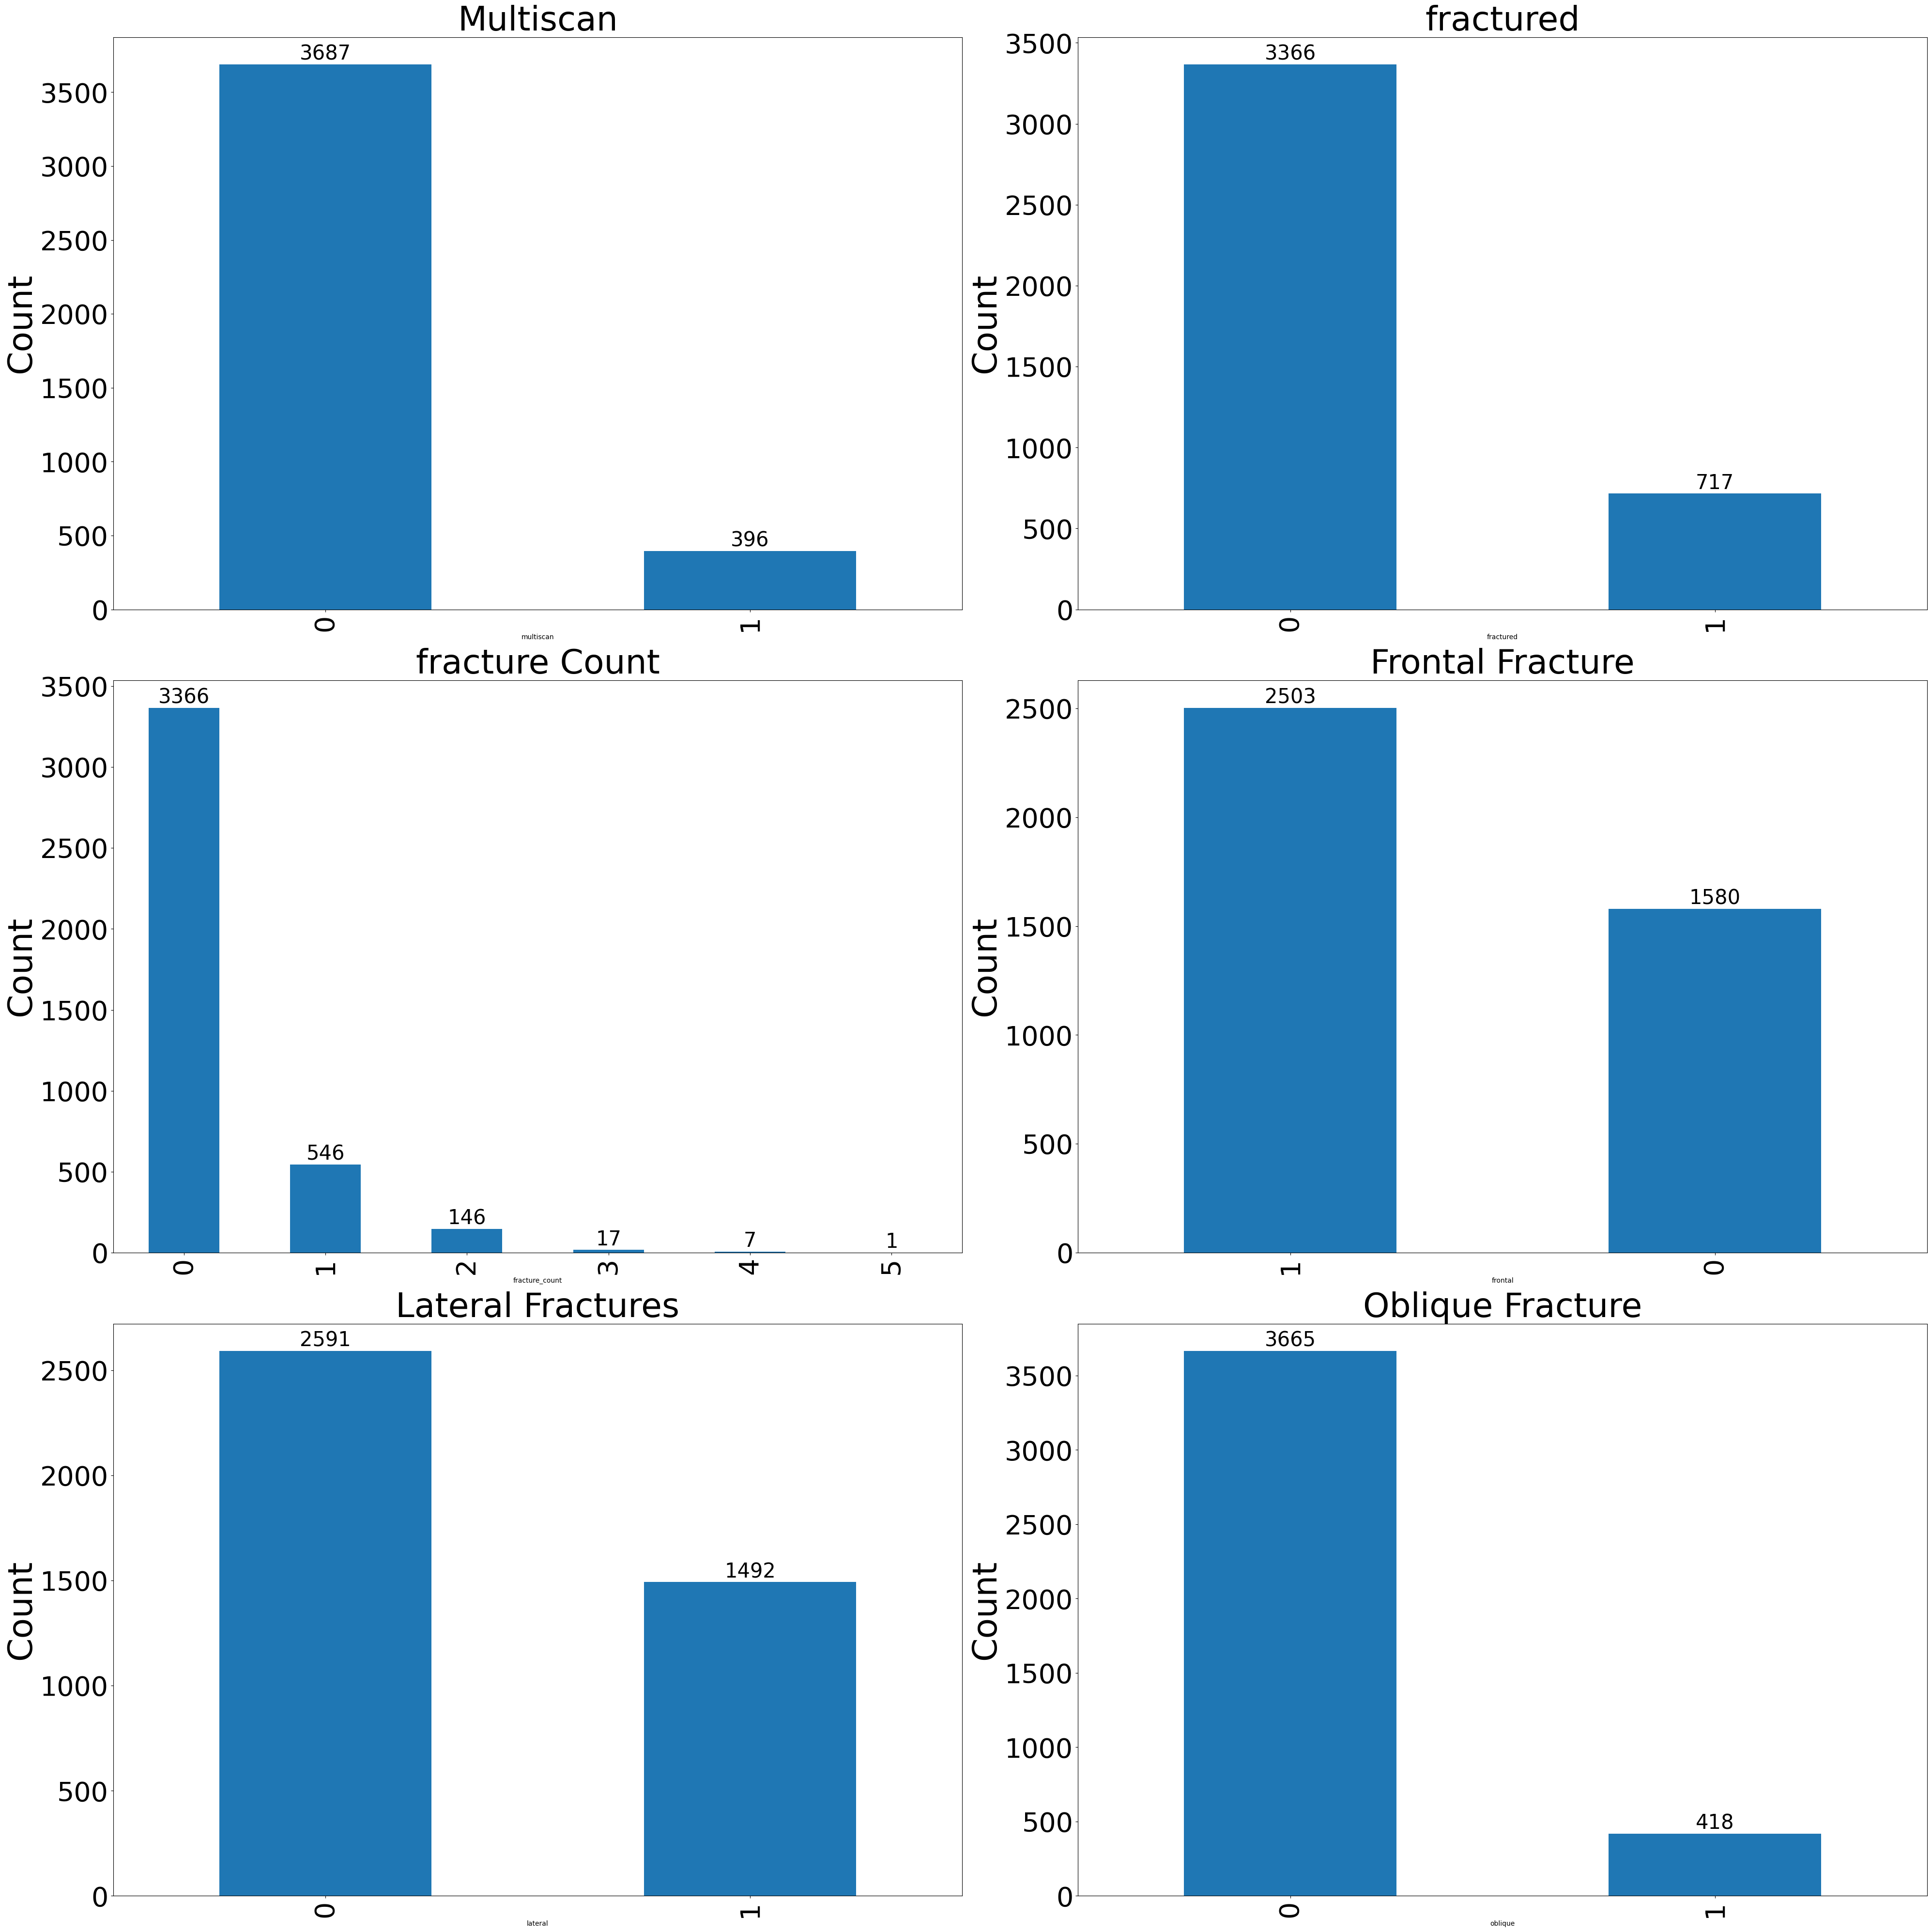

In [15]:
# Getting a sense of what the distribution between fracture types and the presence of hardware

fig = plt.figure(figsize=(40, 40))

# Define font size for tick labels
tick_label_size = 40

ax1 = fig.add_subplot(321)
metadata['multiscan'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_ylabel('Count', size=50)
ax1.set_title('Multiscan', size=50)
ax1.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax1)

ax2 = fig.add_subplot(322)
metadata['fractured'].value_counts().plot(kind='bar', ax=ax2)
ax2.set_ylabel('Count', size=50)
ax2.set_title('fractured', size=50)
ax2.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax2)

ax3 = fig.add_subplot(323)
metadata['fracture_count'].value_counts().plot(kind='bar', ax=ax3)
ax3.set_ylabel('Count', size=50)
ax3.set_title('fracture Count', size=50)
ax3.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax3)

ax4 = fig.add_subplot(324)
metadata['frontal'].value_counts().plot(kind='bar', ax=ax4)
ax4.set_ylabel('Count', size=50)
ax4.set_title('Frontal Fracture', size=50)
ax4.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax4)

ax5 = fig.add_subplot(325)
metadata['lateral'].value_counts().plot(kind='bar', ax=ax5)
ax5.set_ylabel('Count', size=50)
ax5.set_title('Lateral Fractures', size=50)
ax5.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax5)

ax6 = fig.add_subplot(326)
metadata['oblique'].value_counts().plot(kind='bar', ax=ax6)
ax6.set_ylabel('Count', size=50)
ax6.set_title('Oblique Fracture', size=50)
ax6.tick_params(axis='both', labelsize=tick_label_size)
add_labels(ax6)

plt.tight_layout()
plt.show()

### 3. Visualization

#### Representative X-ray Samples Across Anatomical Regions

The cells below show two grid samples of example X-ray images from various anatomical regions—one grid for fractured cases and one for non-fractured. The first four rows contain images that display a single region: hand, leg, hip, or shoulder. The fifth row includes images with mixed regions, while the final row shows cases involving orthopedic hardware.

In [16]:

# Load COCO-style fracture annotation JSON
with open('FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json', 'r') as f:
    coco_data = json.load(f)

# Build a mapping from image_id -> file_name
image_id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}

# Build a mapping from file_name -> list of bounding boxes
coco_boxes = defaultdict(list)

for ann in coco_data['annotations']:
    image_id = ann['image_id']
    file_name = image_id_to_filename[image_id]
    x, y, w, h = ann['bbox']
    coco_boxes[file_name].append({
        'xmin': x,
        'ymin': y,
        'xmax': x + w,
        'ymax': y + h
    })

In [17]:

import matplotlib.pyplot as plt
import cv2
import os

path = os.path.join('FracAtlas', 'images')
def draw_box(img, bbox, color=(255, 0, 0), thickness=7):
    x1, y1, x2, y2 = map(int, [bbox['xmin'], bbox['ymin'], bbox['xmax'], bbox['ymax']])
    img = cv2.rectangle(img.copy(), (x1, y1), (x2, y2), color, thickness)
    return img

def plot_grid(samples_dict, title, coco_boxes_dict=None, show_boxes=False):
    fig, axes = plt.subplots(nrows=len(list(samples_dict.keys())), ncols=5, figsize=(12, 12))
    fig.suptitle(title, fontsize=16)
    
    for i, (region, rows) in enumerate(samples_dict.items()):
        for j, (_, row) in enumerate(rows.iterrows()):
            if row['fractured']:
                img_path = os.path.join(path, 'Fractured', row['image_id'])
            else:
                img_path = os.path.join(path, 'Non_fractured', row['image_id'])
    
                
            file_name = os.path.basename(img_path)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if show_boxes and coco_boxes and file_name in coco_boxes:
                for bbox in coco_boxes[file_name]:
                    img = draw_box(img, bbox)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            axes[i, j].set_title(region.capitalize())

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()







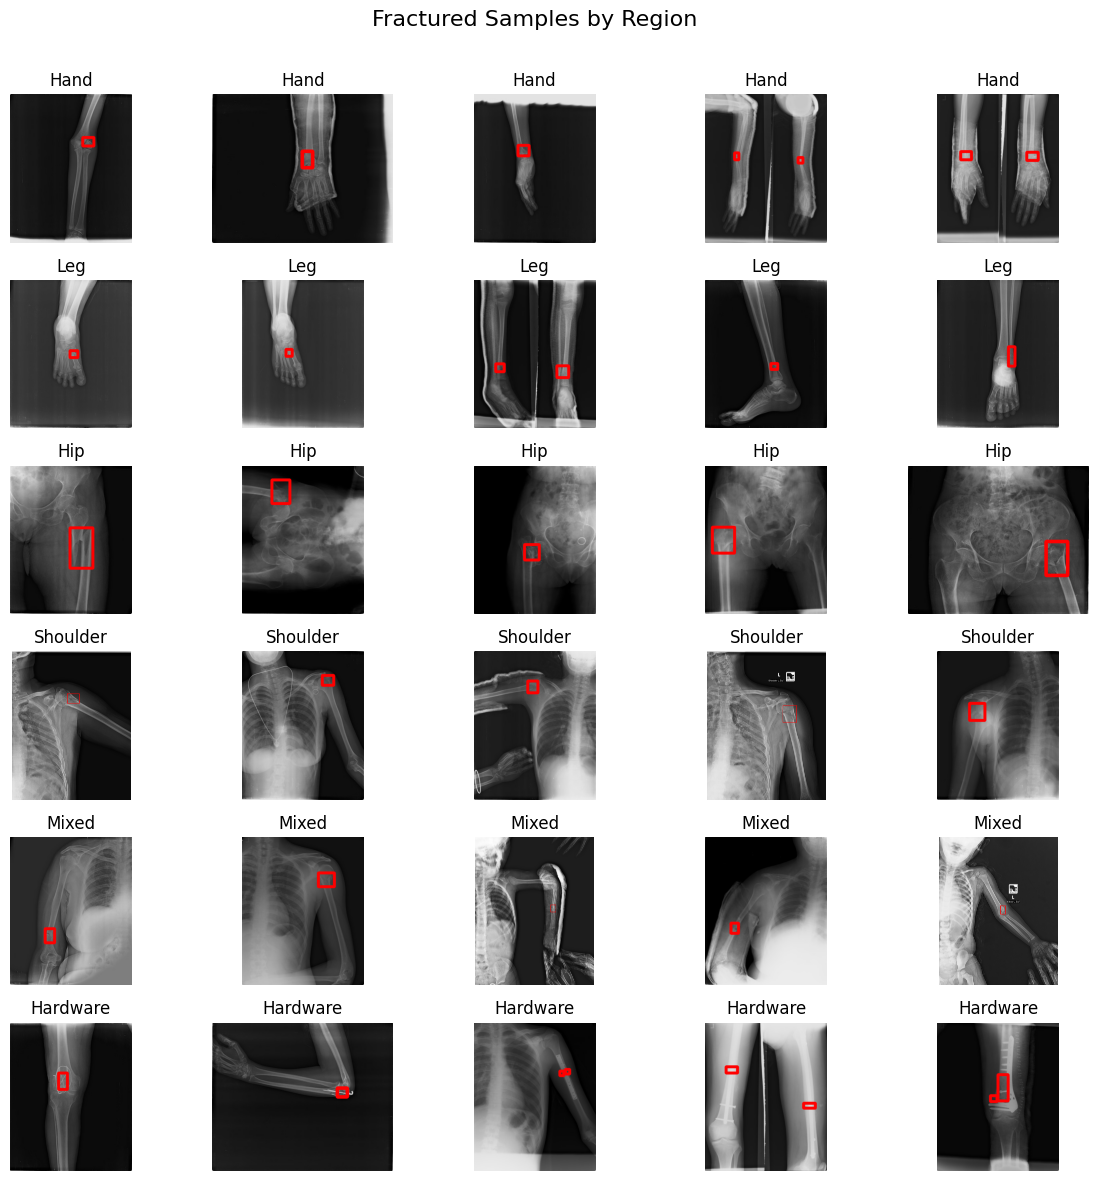

In [18]:
regions = ['hand', 'leg', 'hip', 'shoulder']

fractured_samples = {
    region: metadata[(metadata[region] == 1) & (metadata['mixed'] == 0) & (metadata['hardware'] == 0) & (metadata['fractured'] == 1)].sample(5)
    for region in regions
}

fractured_samples['mixed'] = metadata[(metadata['mixed'] == 1) & (metadata['hardware'] == 0) & (metadata['fractured'] == 1)].sample(5)
fractured_samples['hardware'] = metadata[(metadata['hardware'] == 1) & (metadata['fractured'] == 1)].sample(5)
plot_grid(fractured_samples, "Fractured Samples by Region", show_boxes=True)


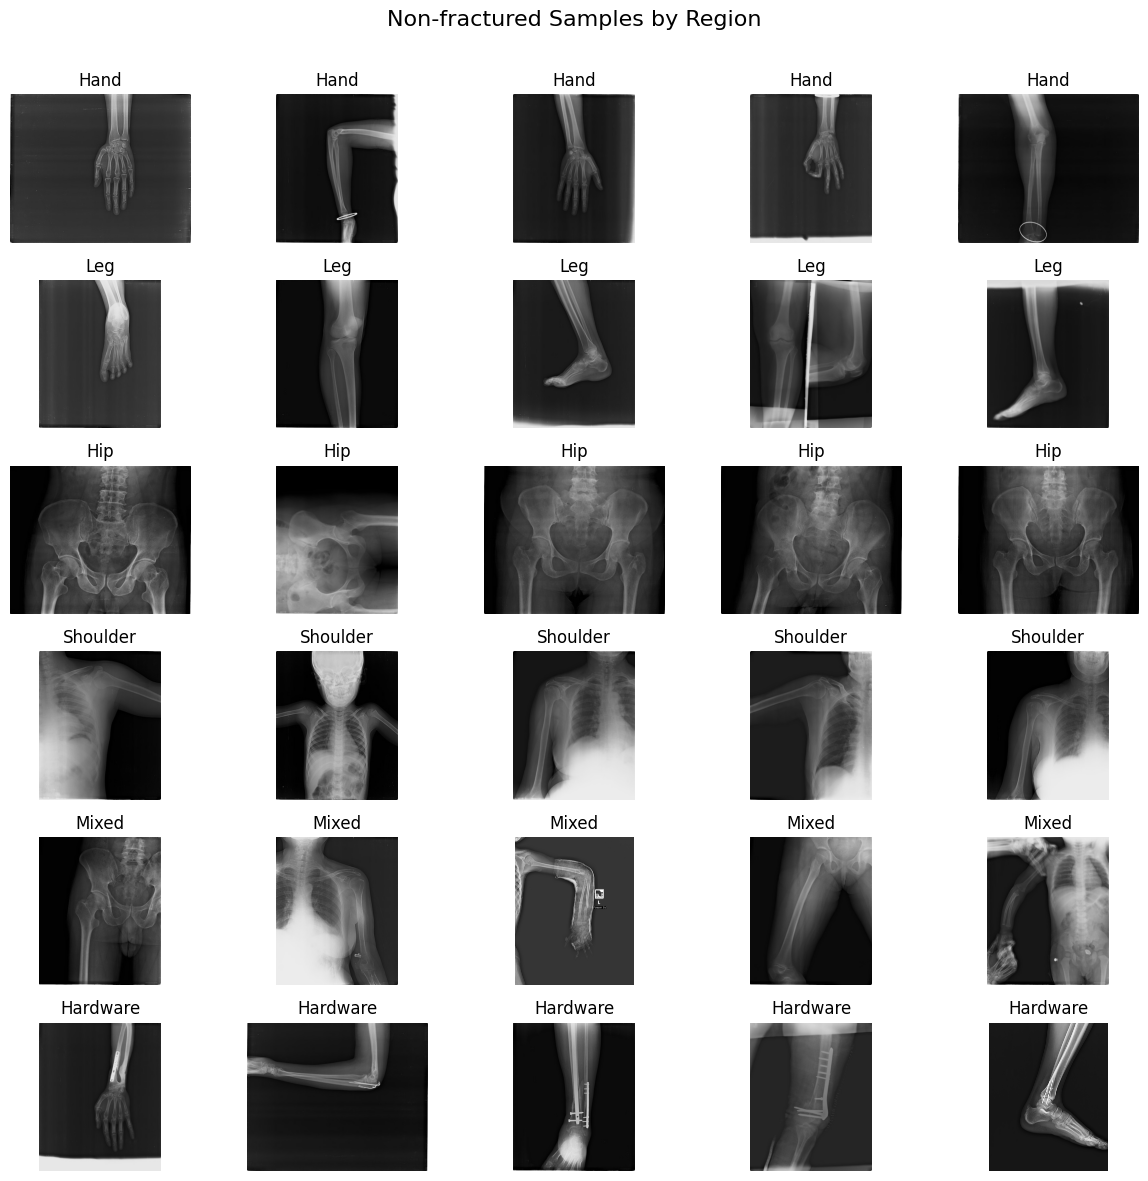

In [19]:
nonfractured_samples = {
    region: metadata[(metadata[region] == 1) & (metadata['fractured'] == 0) & (metadata['mixed'] == 0) & (metadata['hardware'] == 0)].sample(5)
    for region in regions
}
nonfractured_samples['mixed'] = metadata[(metadata['mixed'] == 1) & (metadata['hardware'] == 0)].sample(5)
nonfractured_samples['hardware'] = metadata[(metadata['hardware'] == 1)].sample(5)


plot_grid(nonfractured_samples, "Non-fractured Samples by Region", show_boxes=False)


### 4. Preliminary Plan for Data Pre-processing

As part of the data preparation process for the fracture localization task, all X-ray images in the FracAtlas dataset are to be resized to a consistent input size appropriate for the selected model architecture. Since most pre-trained models require three-channel input, grayscale images will be converted to 3-channel format by duplicating the single channel across RGB dimensions. In addition, image normalization will be applied to ensure consistent pixel value ranges, either through min-max scaling or standardization, depending on the requirements of the model.

Two main sources of imbalance are observed in the dataset: the distribution of anatomical regions and the proportion of fractured versus non-fractured images. Leg and hand regions appear more frequently than hip and shoulder, while non-fractured images significantly outnumber fractured ones. Although the task does not involve region-specific classification, these imbalances may introduce bias during training and affect the model’s ability to generalize across less-represented cases.

To address these issues, the data pipeline will include oversampling strategies to increase the representation of underrepresented classes, both in terms of anatomical regions and fracture presence. Data augmentation techniques will also be applied to enhance variability and reduce overfitting. These augmentations will involve geometric and intensity-based transformations that preserve the anatomical structure of the image and adjust the associated bounding boxes accordingly.

The dataset will be divided into training, validation, and test sets in a way that maintains a balanced distribution of fractured and non-fractured cases, as well as coverage of all anatomical regions. If patient-level identifiers are available, they will be used to create patient-disjoint splits to prevent data leakage. These preprocessing and balancing steps are intended to ensure that the model is trained on clean, representative, and diverse data to support robust fracture localization performance.
